Steps executed in this project is based on "popularity based recommender system".

A.Data loading

1.Loaded the movies and ratings data into pandas DataFrames.


In [2]:
import pandas as pd

try:
    movies = pd.read_csv('movies.csv', dtype={'movieId': 'int64'})
    ratings = pd.read_csv('ratings.csv', dtype={'movieId': 'int64', 'rating': 'float64'})
    display(movies.head())
    display(ratings.head())
except FileNotFoundError:
    print("Error: One or both of the CSV files were not found.")
except pd.errors.ParserError:
    print("Error: There was an issue parsing the CSV file(s).  Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523



2.Merging the two dataframes on 'movieId'.



In [3]:
try:
    movie_ratings = pd.merge(movies, ratings, on='movieId')
    display(movie_ratings.head())
except Exception as e:
    print(f"An error occurred during the merge operation: {e}")

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2,5.0,859046895
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,1303501039
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,8,5.0,858610933
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,11,4.0,850815810
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,14,4.0,851766286



3.Implementing the popularity-based recommendation system based on genre, minimum rating threshold, and the number of recommendations.



In [6]:
def recommend_movies(genre, min_rating_threshold, num_recommendations):
    # Filter movies by genre
    genre_movies = movie_ratings[movie_ratings['genres'].str.contains(genre, na=False)]

    # Calculate the number of ratings for each movie
    movie_popularity = genre_movies.groupby('movieId')['rating'].count().reset_index(name='num_ratings')

    # Merge popularity back into the genre movies dataframe
    genre_movies = pd.merge(genre_movies, movie_popularity, on='movieId')

    # Filter movies with at least min_rating_threshold ratings
    genre_movies_filtered = genre_movies[genre_movies['num_ratings'] >= min_rating_threshold]

    # Sort by rating in descending order
    top_movies = genre_movies_filtered.sort_values(by=['rating'], ascending=False)

    # Return the top N movies
    recommendations = top_movies[['title', 'rating', 'num_ratings']].drop_duplicates().head(num_recommendations)

    return recommendations

# Example usage (you can replace these values)
genre = "Comedy"
min_rating_threshold = 50
num_recommendations = 10

recommendations = recommend_movies(genre, min_rating_threshold, num_recommendations)
display(recommendations)

,title,rating,num_ratings
0,Toy Story (1995),5.0,232
11278,Groundhog Day (1993),5.0,157
4491,Maverick (1994),5.0,85
11120,"Graduate, The (1967)",5.0,87
16643,Splash (1984),5.0,62
4503,Naked Gun 33 1/3: The Final Insult (1994),5.0,69
23235,"League of Their Own, A (1992)",5.0,51
17063,Beetlejuice (1988),5.0,107
23178,Wayne's World (1992),5.0,59
23706,Animal House (1978),5.0,64


B.Data exploration

4.Examined the shape and datatypes of movies,ratings.

 Initial DataFrame Shapes and Types
Movies DataFrame:
(10329, 3)
movieId     int64
title      object
genres     object
dtype: object

Ratings DataFrame:
(105339, 4)
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

Merged movie_ratings DataFrame:
(105339, 6)
movieId        int64
title         object
genres        object
userId         int64
rating       float64
timestamp      int64
dtype: object

 Missing Values 

Missing values in Movies DataFrame:
movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings DataFrame:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in Merged movie_ratings DataFrame:
movieId      0
title        0
genres       0
userId       0
rating       0
timestamp    0
dtype: int64

 User and Movie Counts 
Total unique users: 668
Total unique movies (from movies.csv): 10329
Total unique movies (from ratings.csv): 10325

 Rating Distribution 
Rating distributi

,rating
genre,
Film-Noir,3.913636
War,3.783202
Mystery,3.652043
Drama,3.650266
Documentary,3.643035
Crime,3.642392
IMAX,3.641821
Animation,3.635350
Musical,3.571962



Total unique movies count per individual genre (same as above):
genres
Drama                 5220
Comedy                3515
Thriller              2187
Romance               1788
Action                1737
Crime                 1440
Adventure             1164
Horror                1001
Sci-Fi                 860
Mystery                675
Fantasy                670
Children               540
War                    503
Documentary            415
Musical                409
Animation              401
Western                235
Film-Noir              195
IMAX                   152
(no genres listed)       7
Name: count, dtype: int64

 Distribution of Ratings per Movie 

Distribution of number of ratings per movie (describe):
count    10325.000000
mean        10.202324
std         22.832341
min          1.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        325.000000
dtype: float64

 Distribution of Movies Rated per User

Distribution of number of movies rat

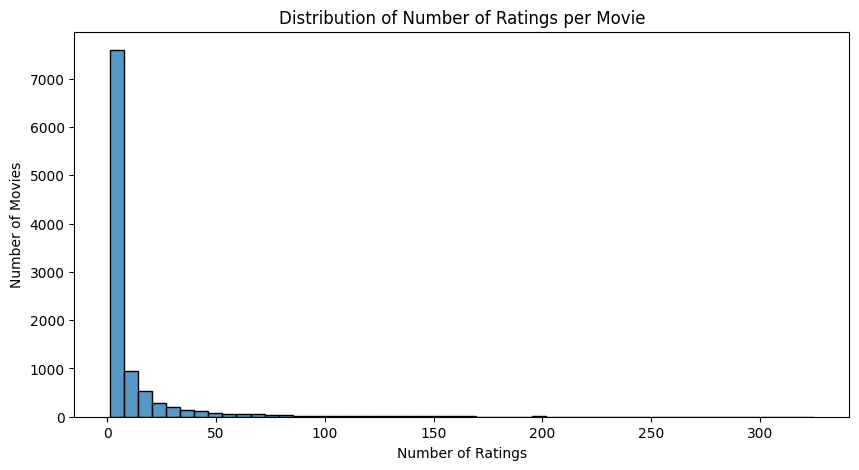

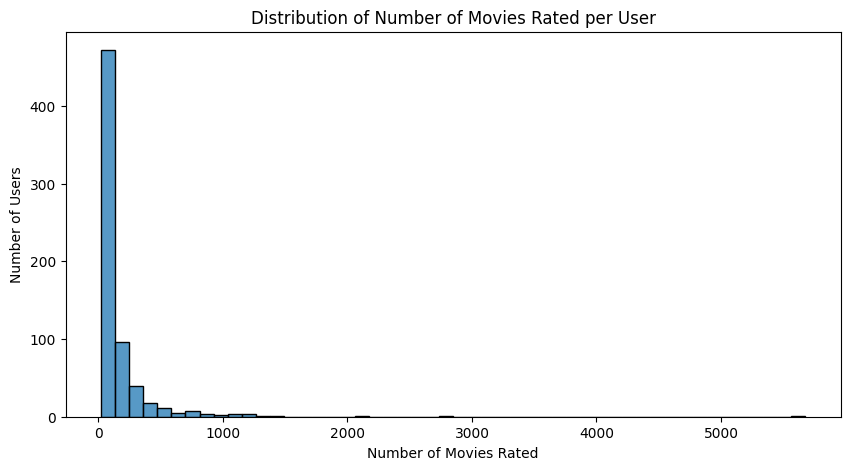


 Exploratory data Analysis Complete


In [35]:


# Examine the shape and data types (already present, keeping for completeness)
print(" Initial DataFrame Shapes and Types")
print("Movies DataFrame:")
print(movies.shape)
print(movies.dtypes)

print("\nRatings DataFrame:")
print(ratings.shape)
print(ratings.dtypes)

print("\nMerged movie_ratings DataFrame:")
print(movie_ratings.shape)
print(movie_ratings.dtypes)


# Check for missing values (already present, keeping for completeness)
print("\n Missing Values ")
print("\nMissing values in Movies DataFrame:")
print(movies.isnull().sum())

print("\nMissing values in Ratings DataFrame:")
print(ratings.isnull().sum())

print("\nMissing values in Merged movie_ratings DataFrame:")
print(movie_ratings.isnull().sum()) # Check missing values after merge


# Exploratory data analysis tasks

print("\n User and Movie Counts ")
# Unique users
unique_users = ratings['userId'].nunique()
print(f"Total unique users: {unique_users}")

# Unique movies
unique_movies_movies_df = movies['movieId'].nunique()
unique_movies_ratings_df = ratings['movieId'].nunique()
print(f"Total unique movies (from movies.csv): {unique_movies_movies_df}")
print(f"Total unique movies (from ratings.csv): {unique_movies_ratings_df}")


print("\n Rating Distribution ")
# Analyze the distribution of ratings (already present, keeping for completeness)
print("Rating distribution:")
print(ratings['rating'].describe())

# Detailed rating value counts
print("\nRating value counts:")
print(ratings['rating'].value_counts().sort_index())


print("\n Genre Analysis ")
# Understanding unique genres
# The 'genres' column is a string with multiple genres separated by '|'
# We need to split this to get individual genres.
all_genres = movies['genres'].str.split('|').explode()
unique_genres = all_genres.unique()
print(f"Total unique genre combinations: {movies['genres'].nunique()}")
print(f"Total individual unique genres: {len(unique_genres)}")
print("\nList of unique individual genres:")
print(unique_genres)


print("\n Aggregated Genre Level Analysis ")
# Total movies per genre
# We need to count movies for each individual genre.
# This involves splitting the genres string and then counting per genre.
genre_counts = all_genres.value_counts()
print("\nTotal movies per individual genre:")
print(genre_counts)

# Average rating per genre is tricky because a movie can belong to multiple genres.
# A common approach is to calculate the average rating for each movie first,and then average those movie averages for each genre they belong to.
#Or, average all ratings for all movies belonging to a genre (which is simpler but can be skewed).
#  average of all ratings for movies tagged with a genre.

# To do this, we need to join ratings back to the split genres.

# First, ensuring movie_ratings has the correct structure.
if 'num_ratings' in movie_ratings.columns: # Remove if added in previous steps to avoid confusion
     movie_ratings = movie_ratings.drop('num_ratings', axis=1)

# Re-merge if necessary to ensure it has original data + ratings
try:
    movie_ratings_for_genre_analysis = pd.merge(movies, ratings, on='movieId')
except Exception as e:
     print(f"Error merging for genre analysis: {e}")

# Split genres in the merged dataframe
movie_ratings_for_genre_analysis['genre'] = movie_ratings_for_genre_analysis['genres'].str.split('|')
movie_ratings_exploded = movie_ratings_for_genre_analysis.explode('genre')

# Calculate average rating per individual genre
avg_rating_per_genre = movie_ratings_exploded.groupby('genre')['rating'].mean().sort_values(ascending=False)
print("\n Average rating per individual genre:")
display(avg_rating_per_genre)

# Total unique movies at genre level (based on individual genres)
# This is the same as genre_counts calculated above.
print("\nTotal unique movies count per individual genre (same as above):")
print(genre_counts)

# Understanding distribution of features (beyond basic describe)
# Distribution of number of ratings per movie
print("\n Distribution of Ratings per Movie ")
ratings_per_movie = movie_ratings.groupby('movieId').size()
print("\nDistribution of number of ratings per movie (describe):")
print(ratings_per_movie.describe())

# Distribution of number of movies rated per user
print("\n Distribution of Movies Rated per User")
movies_per_user = movie_ratings.groupby('userId').size()
print("\nDistribution of number of movies rated per user (describe):")
print(movies_per_user.describe())

# visualizing these distributions using histograms (e.g., with matplotlib or seaborn)
# For example:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.histplot(ratings_per_movie, bins=50)
plt.title('Distribution of Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(movies_per_user, bins=50)
plt.title('Distribution of Number of Movies Rated per User')
plt.xlabel('Number of Movies Rated')
plt.ylabel('Number of Users')
plt.show()

print("\n Exploratory data Analysis Complete")

C.Data wrangling


5.Merged the movies and ratings dataframes by movie_id, calculated the number of ratings per movie,and stored this count in a new column named `num_ratings`.Then merged this new column back into the merged DataFrame. Finally, defined the filter function based on a minimum rating threshold.


In [7]:
# Calculate the number of ratings per movie
num_ratings = movie_ratings.groupby('movieId')['rating'].count().reset_index(name='num_ratings')

# Merge the number of ratings back into the movie_ratings DataFrame
movie_ratings = pd.merge(movie_ratings, num_ratings, on='movieId')

def filter_movies(min_rating_threshold):
    """Filters movies based on a minimum rating threshold.

    Args:
        min_rating_threshold: The minimum number of ratings a movie must have to be included.

    Returns:
        A DataFrame containing only the movies that meet the minimum rating threshold.
    """
    filtered_df = movie_ratings[movie_ratings['num_ratings'] >= min_rating_threshold]
    return filtered_df

D.Data preparation

6.Grouped the merged movie_ratings dataframe by genre, sorted movies by average rating within each genre, and filtered movies based on the minimum rating threshold.


In [8]:
def group_and_filter(df, min_rating_threshold):
    """Groups movies by genre, sorts by average rating, and filters by minimum rating count."""
    try:
        grouped_movies = df.groupby('genres').agg({'rating': 'mean', 'num_ratings':'first', 'title':'first'}).reset_index()
        grouped_movies = grouped_movies.sort_values(by=['genres', 'rating'], ascending=[True, False])
        filtered_movies = grouped_movies[grouped_movies['num_ratings'] >= min_rating_threshold]
        return filtered_movies
    except KeyError as e:
        print(f"Error: Column '{e}' not found in the DataFrame.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

7.Minimum ratings threshold



In [39]:
# Drop the existing num_ratings column if it exists
if 'num_ratings' in movie_ratings.columns:
    movie_ratings = movie_ratings.drop('num_ratings', axis=1)

# Recalculate num_ratings and merge correctly
def recommend_movies(genre, min_rating_threshold, num_recommendations):
    # Filter movies by genre
    genre_movies = movie_ratings[movie_ratings['genres'].str.contains(genre, na=False)]

    # Recalculate num_ratings, making sure to use movieId
    movie_popularity = genre_movies.groupby('movieId')['rating'].count().reset_index(name='num_ratings')

    # Merge using the correct column and how
    genre_movies = pd.merge(genre_movies, movie_popularity, on='movieId', how='left')

    # Filter movies with at least min_rating_threshold ratings
    genre_movies_filtered = genre_movies[genre_movies['num_ratings'] >= min_rating_threshold]

    # Sort by rating in descending order
    top_movies = genre_movies_filtered.sort_values(by=['rating'], ascending=False)

    # Return the top N movies
    recommendations = top_movies[['title', 'rating', 'num_ratings']].drop_duplicates().head(num_recommendations)

    return recommendations

# Example usage
genre = "Comedy"
min_rating_threshold = 50
num_recommendations = 10

recommendations = recommend_movies(genre, min_rating_threshold, num_recommendations)
display(recommendations)

,title,rating,num_ratings
0,Toy Story (1995),5.0,232
11278,Groundhog Day (1993),5.0,157
4491,Maverick (1994),5.0,85
11120,"Graduate, The (1967)",5.0,87
16643,Splash (1984),5.0,62
4503,Naked Gun 33 1/3: The Final Insult (1994),5.0,69
23235,"League of Their Own, A (1992)",5.0,51
17063,Beetlejuice (1988),5.0,107
23178,Wayne's World (1992),5.0,59
23706,Animal House (1978),5.0,64


E.Model evaluation



8.Model evaluation output based on given genre ,min_review_threshold,number of recommendations.

In [40]:
# Example usage (from your code)
genre = "Comedy"
min_reviews_threshold = 100
num_recommendations = 5

# Evaluation
print("Evaluation Results")
# Print a header for the formatted output
print(f"{'S.No':<5} | {'Movie Title':<40} | {'Avg movie_Rating':<10} | {'Num Reviews':<12}")
print("-" * 5 + "-|-" + "-" * 40 + "-|-" + "-" * 10 + "-|-" + "-" * 12)

# Iterate through the recommendations and print details
for index, row in recommendations.iterrows():
    # Get the serial number (starting from 1)
    serial_number = index + 1
    movie_title = row['title']
    movie_rating = row['rating']
    num_ratings_movie = row['num_ratings']

    # Print the formatted movie details
    print(f"{serial_number:<5} | {movie_title:<40} | {movie_rating:<10.2f} | {num_ratings_movie:<12}")

print("\nRecommendations successfully evaluated.")


 Evaluation Results 
S.No  | Movie Title                              | Avg movie_Rating | Num Reviews 
------|------------------------------------------|------------|-------------
1     | Toy Story (1995)                         | 5.00       | 232         
11279 | Groundhog Day (1993)                     | 5.00       | 157         
4492  | Maverick (1994)                          | 5.00       | 85          
11121 | Graduate, The (1967)                     | 5.00       | 87          
16644 | Splash (1984)                            | 5.00       | 62          
4504  | Naked Gun 33 1/3: The Final Insult (1994) | 5.00       | 69          
23236 | League of Their Own, A (1992)            | 5.00       | 51          
17064 | Beetlejuice (1988)                       | 5.00       | 107         
23179 | Wayne's World (1992)                     | 5.00       | 59          
23707 | Animal House (1978)                      | 5.00       | 64          

Recommendations successfully evaluated.





Key Findings
* The final recommendation system successfully suggests movies based on genre, minimum rating threshold, and the number of recommendations requested.
* The system uses a popularity-based approach, ranking movies by average rating within a genre, considering the number of ratings each movie received.


Insights
* **Improve Recommendation Diversity:** Explore techniques to diversify recommendations, as the current system primarily focuses on the highest-rated movies.  Consider incorporating other factors like genre diversity or introducing a "surprise me" option.
* **Explore Alternative Metrics:** Evaluate alternative metrics beyond average rating, such as weighted average ratings or Bayesian average ratings, to account for the number of ratings more effectively.
